<a href="https://colab.research.google.com/github/AsimaZaheer/Stress-Detection/blob/main/CNN%2BLSTM%2BLOSO_implementation%20murtaza%20v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
[INFO] WESAD ZIP found: /content/drive/MyDrive/WESAD/WESAD.zip
[INFO] No WESAD subject pickle files found.
[INFO] Extracting WESAD.zip...
[INFO] Extraction completed.
[INFO] Using device: cuda

  SUBJECT-INDEPENDENT STRESS DETECTION FRAMEWORK (v3)
  LOSO | Multi-Rate Multi-Modal CNN-BiGRU + Features
  Subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

WESAD DATASET VERIFICATION
[OK]      S2: /content/WESAD/S2/S2.pkl
[OK]      S3: /content/WESAD/S3/S3.pkl
[OK]      S4: /content/WESAD/S4/S4.pkl
[OK]      S5: /content/WESAD/S5/S5.pkl
[OK]      S6: /content/WESAD/S6/S6.pkl
[OK]      S7: /content/WESAD/S7/S7.pkl
[OK]      S8: /content/WESAD/S8/S8.pkl
[OK]      S9: /content/WESAD/S9/S9.pkl
[OK]      S10: /content/WESAD/S10/S10.pkl
[OK]      S11: /content/WESAD/S11/S11.pkl
[OK]      S13: /content/WESAD/S13/S13.pkl
[OK]      S14: /content/WESAD/S14/S14.pkl
[OK]      S15: /content/WESAD/S15/S15.pkl
[OK]      S16

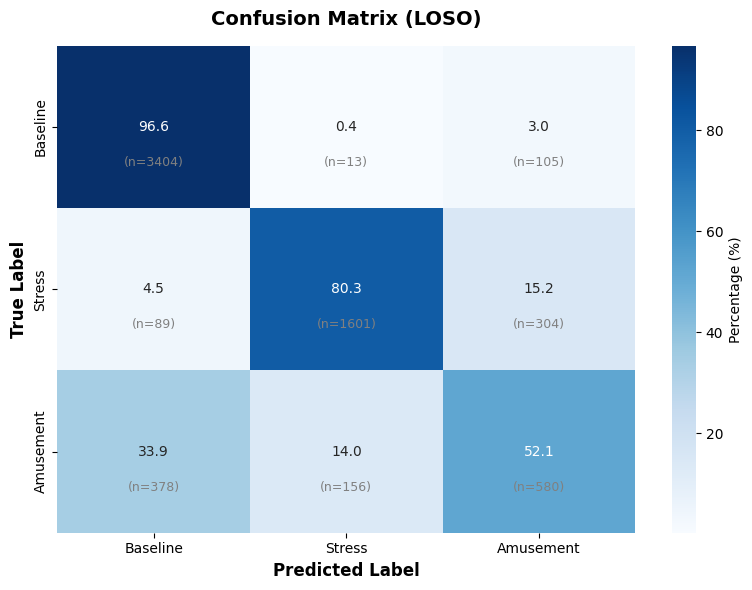


Confusion Matrix (Counts):
           Baseline  Stress  Amusement
Baseline       3404      13        105
Stress           89    1601        304
Amusement       378     156        580

Confusion Matrix (Row %):
           Baseline  Stress  Amusement
Baseline      96.65    0.37       2.98
Stress         4.46   80.29      15.25
Amusement     33.93   14.00      52.06

  PIPELINE COMPLETE

Important:
- The test subject was not used for checkpoint selection.
- Scaling was fitted using training subjects only.
- Validation subjects were used for early stopping.
- The final reported test results are from held-out subjects.

Possible next experiments:
1. WeightedRandomSampler for Amusement.
2. STEP_SEC=3 for more windows.
3. Add chest-device respiration/ECG features if available.
4. Compare against Random Forest/XGBoost using handcrafted features.


In [2]:
#!/usr/bin/env python3
"""
WESAD SUBJECT-INDEPENDENT STRESS DETECTION FRAMEWORK (v3)

LOSO Cross-Validation
Multi-Rate Multi-Modal CNN-BiGRU + Handcrafted Features
Google Colab + Google Drive
Robust WESAD ZIP/FOLDER detection

IMPORTANT:
- Put WESAD.zip in: /content/drive/MyDrive/WESAD.zip
- Run this entire file/cell.
- The loader searches recursively, so extra ZIP folders are okay.
- S1 and S12 are excluded.
"""

# =============================================================================
# 1. GOOGLE DRIVE + ROBUST DATASET SETUP
# =============================================================================

import os
import sys
import copy
import pickle
import zipfile
import shutil
import warnings

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

    WESAD_ZIP = "/content/drive/MyDrive/WESAD/WESAD.zip"
    WESAD_DIR = "/content/WESAD"

    if not os.path.isfile(WESAD_ZIP):
        raise FileNotFoundError(
            "\nWESAD.zip was not found at:\n"
            f"{WESAD_ZIP}\n\n"
            "Upload WESAD.zip to Google Drive > MyDrive and run again."
        )

    print(f"[INFO] WESAD ZIP found: {WESAD_ZIP}")

    # Search for existing subject pickles anywhere under /content.
    existing_subject_files = {}
    for root, dirs, files in os.walk("/content"):
        for filename in files:
            if filename.lower().endswith(".pkl"):
                stem = os.path.splitext(filename)[0].upper()
                if stem.startswith("S") and stem[1:].isdigit():
                    existing_subject_files[stem] = os.path.join(root, filename)

    if len(existing_subject_files) == 0:
        print("[INFO] No WESAD subject pickle files found.")
        print("[INFO] Extracting WESAD.zip...")

        # Remove only the expected extraction directory if it exists.
        if os.path.exists(WESAD_DIR):
            print(f"[INFO] Removing incomplete directory: {WESAD_DIR}")
            shutil.rmtree(WESAD_DIR)

        with zipfile.ZipFile(WESAD_ZIP, "r") as z:
            z.extractall("/content")

        print("[INFO] Extraction completed.")

    else:
        print(
            f"[INFO] Found {len(existing_subject_files)} existing pickle file(s). "
            "Using existing extracted data."
        )

else:
    WESAD_DIR = "./WESAD"
    WESAD_ZIP = None
    print(f"[WARNING] Not running in Colab. Assuming dataset is at {WESAD_DIR}")


# =============================================================================
# 2. LIBRARIES
# =============================================================================

import numpy as np
import pandas as pd

from scipy import stats
from scipy.signal import resample, find_peaks, butter, filtfilt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# =============================================================================
# 3. CONFIGURATION
# =============================================================================

ALL_SUBJECTS = [
    f"S{i}" for i in range(2, 18) if i != 12
]

BVP_SR = 64
ACC_SR = 32
EDA_SR = 4
TEMP_SR = 4
LABEL_SR = 700

HR_SR = 32
LR_SR = 4

WINDOW_SEC = 60
STEP_SEC = 5

HR_LEN = WINDOW_SEC * HR_SR
LR_LEN = WINDOW_SEC * LR_SR

FEAT_DIM = 14

VALID_LABELS_ORIG = [1, 2, 3]
LABEL_MAP = {
    1: 0,  # Baseline
    2: 1,  # Stress
    3: 2,  # Amusement
}

CLASS_NAMES = [
    "Baseline",
    "Stress",
    "Amusement",
]

NUM_CLASSES = 3

BATCH_SIZE = 64
EPOCHS = 40
EARLY_STOP_PATIENCE = 8

LEARNING_RATE = 7e-4
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.35
GRAD_CLIP_NORM = 5.0

SEED = 42
NUM_WORKERS = 0
# Always drop an incomplete final training batch.
TRAIN_DROP_LAST = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"[INFO] Using device: {DEVICE}")

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# =============================================================================
# 4. ROBUST WESAD FILE SEARCH
# =============================================================================

def find_subject_pickle(subject_id, search_roots=None):
    """
    Find <subject_id>.pkl recursively.

    This handles structures such as:
        /content/WESAD/S2/S2.pkl
        /content/WESAD/S2.pkl
        /content/WESAD/WESAD/S2/S2.pkl
        /content/S2/S2.pkl
    """

    subject_id = subject_id.upper()

    if search_roots is None:
        search_roots = []

        if os.path.exists("/content"):
            search_roots.append("/content")

        if os.path.exists(WESAD_DIR):
            search_roots.append(WESAD_DIR)

        if not IN_COLAB and os.path.exists("."):
            search_roots.append(".")

    # Remove duplicate roots while preserving order.
    unique_roots = []
    for root in search_roots:
        root = os.path.abspath(root)
        if root not in unique_roots and os.path.exists(root):
            unique_roots.append(root)

    target = f"{subject_id}.pkl"

    candidates = []

    for root in unique_roots:
        for current_root, dirs, files in os.walk(root):
            # Exact filename first.
            for filename in files:
                if filename.lower() == target.lower():
                    candidates.append(
                        os.path.join(current_root, filename)
                    )

    # Prefer paths that actually contain the subject folder.
    candidates.sort(
        key=lambda p: (
            0 if os.path.basename(os.path.dirname(p)).upper() == subject_id else 1,
            len(p),
        )
    )

    if candidates:
        return candidates[0]

    return None


def load_subject_data(subject_id, wesad_dir=None):
    """
    Load one WESAD subject pickle using robust recursive search.
    """

    if wesad_dir is None:
        wesad_dir = WESAD_DIR

    pkl_path = find_subject_pickle(subject_id)

    if pkl_path is None:
        raise FileNotFoundError(
            f"Cannot find {subject_id}.pkl under /content.\n"
            f"Expected something like:\n"
            f"  {wesad_dir}/{subject_id}/{subject_id}.pkl"
        )

    print(f"  [FOUND] {pkl_path}")

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    if not isinstance(data, dict):
        raise ValueError(
            f"{subject_id}.pkl loaded, but the content is not a dictionary."
        )

    if "signal" not in data or "wrist" not in data["signal"]:
        raise ValueError(
            f"{subject_id}.pkl does not contain signal['wrist']."
        )

    return data


# =============================================================================
# 5. DATASET VERIFICATION
# =============================================================================

def verify_wesad_subjects():
    """
    Check which expected subjects can actually be found.
    """

    print("\n" + "=" * 70)
    print("WESAD DATASET VERIFICATION")
    print("=" * 70)

    found = {}
    missing = []

    for subject in ALL_SUBJECTS:
        path = find_subject_pickle(subject)

        if path is not None:
            found[subject] = path
            print(f"[OK]      {subject}: {path}")
        else:
            missing.append(subject)
            print(f"[MISSING] {subject}")

    print("-" * 70)
    print(
        f"[INFO] Found {len(found)}/{len(ALL_SUBJECTS)} "
        f"expected subjects."
    )

    if missing:
        print(f"[INFO] Missing subjects: {missing}")

    print("=" * 70)

    return found


# =============================================================================
# 6. WRIST SIGNAL EXTRACTION
# =============================================================================

def extract_wrist_signals(subject_data):
    """
    Extract:
      BVP
      EDA
      TEMP
      ACC magnitude
      labels
    """

    wrist_data = subject_data["signal"]["wrist"]

    required = ["BVP", "EDA", "TEMP", "ACC"]

    for key in required:
        if key not in wrist_data:
            raise KeyError(
                f"Missing wrist signal: {key}"
            )

    if "label" not in subject_data:
        raise KeyError("Missing subject label.")

    bvp = np.asarray(
        wrist_data["BVP"]
    ).flatten().astype(np.float32)

    eda = np.asarray(
        wrist_data["EDA"]
    ).flatten().astype(np.float32)

    temp = np.asarray(
        wrist_data["TEMP"]
    ).flatten().astype(np.float32)

    acc = np.asarray(
        wrist_data["ACC"]
    ).astype(np.float32)

    if acc.ndim != 2 or acc.shape[1] != 3:
        raise ValueError(
            f"ACC has unexpected shape: {acc.shape}"
        )

    acc_mag = np.sqrt(
        np.sum(acc ** 2, axis=1)
    ).astype(np.float32)

    labels = np.asarray(
        subject_data["label"]
    ).flatten()

    return (
        bvp,
        eda,
        temp,
        acc_mag,
        labels,
    )


# =============================================================================
# 7. EDA PROCESSING
# =============================================================================

def decompose_eda(eda_seg, fs=EDA_SR):
    """
    Split EDA into tonic and phasic components.
    """

    eda_seg = np.asarray(
        eda_seg,
        dtype=np.float64
    )

    if len(eda_seg) == 0:
        return (
            np.zeros(0),
            np.zeros(0)
        )

    if len(eda_seg) < fs * 4:
        mean_value = np.mean(eda_seg)

        tonic = np.full_like(
            eda_seg,
            mean_value
        )

    else:
        try:
            b, a = butter(
                2,
                0.05 / (fs / 2),
                btype="low"
            )

            tonic = filtfilt(
                b,
                a,
                eda_seg
            )

        except Exception:
            tonic = np.full_like(
                eda_seg,
                np.mean(eda_seg)
            )

    phasic = eda_seg - tonic

    return tonic, phasic


# =============================================================================
# 8. HRV FEATURES
# =============================================================================

def compute_hrv_features(
    bvp_seg,
    fs=BVP_SR
):
    """
    Return:
      mean HR
      HR std
      RMSSD
      HR range
      beat count
    """

    if len(bvp_seg) < fs * 5:
        return np.zeros(
            5,
            dtype=np.float32
        )

    sig = np.asarray(
        bvp_seg,
        dtype=np.float64
    )

    sig = sig - np.mean(sig)

    min_distance = max(
        int(fs * 60 / 180),
        1
    )

    try:
        peaks, _ = find_peaks(
            sig,
            distance=min_distance
        )
    except Exception:
        return np.zeros(
            5,
            dtype=np.float32
        )

    if len(peaks) < 3:
        return np.zeros(
            5,
            dtype=np.float32
        )

    ibi = np.diff(peaks) / fs

    if len(ibi) == 0:
        return np.zeros(
            5,
            dtype=np.float32
        )

    hr = 60.0 / ibi

    valid = (
        (hr > 30)
        & (hr < 220)
        & np.isfinite(hr)
    )

    hr = hr[valid]

    if len(hr) < 2:
        return np.zeros(
            5,
            dtype=np.float32
        )

    mean_hr = np.mean(hr)
    std_hr = np.std(hr)
    hr_range = np.max(hr) - np.min(hr)

    ibi_valid = 60.0 / hr

    if len(ibi_valid) > 1:
        rmssd = np.sqrt(
            np.mean(
                np.diff(ibi_valid) ** 2
            )
        )
    else:
        rmssd = 0.0

    beat_count = float(len(hr))

    return np.array(
        [
            mean_hr,
            std_hr,
            rmssd,
            hr_range,
            beat_count,
        ],
        dtype=np.float32
    )


# =============================================================================
# 9. EDA FEATURES
# =============================================================================

def compute_eda_features(
    eda_seg,
    fs=EDA_SR
):
    """
    Return:
      mean SCL
      SCR count
      mean SCR amplitude
      phasic standard deviation
    """

    if len(eda_seg) < fs * 10:
        return np.zeros(
            4,
            dtype=np.float32
        )

    tonic, phasic = decompose_eda(
        eda_seg,
        fs
    )

    try:
        scr_peaks, _ = find_peaks(
            phasic,
            height=0.01,
            distance=max(fs, 1)
        )
    except Exception:
        scr_peaks = np.array(
            [],
            dtype=int
        )

    mean_scl = float(
        np.mean(tonic)
    )

    scr_count = float(
        len(scr_peaks)
    )

    if len(scr_peaks) > 0:
        mean_scr_amp = float(
            np.mean(
                phasic[scr_peaks]
            )
        )
    else:
        mean_scr_amp = 0.0

    phasic_std = float(
        np.std(phasic)
    )

    return np.array(
        [
            mean_scl,
            scr_count,
            mean_scr_amp,
            phasic_std,
        ],
        dtype=np.float32
    )


# =============================================================================
# 10. ACC FEATURES
# =============================================================================

def compute_acc_features(acc_seg):
    """
    Return:
      mean movement
      std movement
      max movement
    """

    if len(acc_seg) == 0:
        return np.zeros(
            3,
            dtype=np.float32
        )

    return np.array(
        [
            np.mean(acc_seg),
            np.std(acc_seg),
            np.max(acc_seg),
        ],
        dtype=np.float32
    )


# =============================================================================
# 11. TEMP FEATURES
# =============================================================================

def compute_temp_features(temp_seg):
    """
    Return:
      mean temperature
      linear temperature slope
    """

    if len(temp_seg) < 2:
        return np.zeros(
            2,
            dtype=np.float32
        )

    mean_temp = np.mean(
        temp_seg
    )

    x = np.arange(
        len(temp_seg),
        dtype=np.float64
    )

    try:
        slope = np.polyfit(
            x,
            temp_seg,
            1
        )[0]
    except Exception:
        slope = 0.0

    return np.array(
        [
            mean_temp,
            slope,
        ],
        dtype=np.float32
    )


# =============================================================================
# 12. MULTI-RATE WINDOW CREATION
# =============================================================================

def create_multirate_windows(
    bvp,
    eda,
    temp,
    acc_mag,
    labels
):
    """
    Build 60-second windows with 5-second stride.

    HR branch:
        BVP + ACC at 32 Hz

    LR branch:
        EDA tonic + EDA phasic + TEMP at 4 Hz

    Handcrafted features:
        14 total

    Window label:
        majority label among labels 1,2,3
    """

    duration = min(
        len(bvp) / BVP_SR,
        len(eda) / EDA_SR,
        len(temp) / TEMP_SR,
        len(acc_mag) / ACC_SR,
        len(labels) / LABEL_SR,
    )

    hr_windows = []
    lr_windows = []
    feat_windows = []
    win_labels = []

    start = 0.0

    while start + WINDOW_SEC <= duration:

        end = start + WINDOW_SEC

        bvp_seg = bvp[
            int(start * BVP_SR):
            int(end * BVP_SR)
        ]

        acc_seg = acc_mag[
            int(start * ACC_SR):
            int(end * ACC_SR)
        ]

        eda_seg = eda[
            int(start * EDA_SR):
            int(end * EDA_SR)
        ]

        temp_seg = temp[
            int(start * TEMP_SR):
            int(end * TEMP_SR)
        ]

        label_seg = labels[
            int(start * LABEL_SR):
            int(end * LABEL_SR)
        ]

        if len(label_seg) == 0:
            start += STEP_SEC
            continue

        # ---------------------------------------------------------
        # Majority label
        # ---------------------------------------------------------

        try:
            majority_result = stats.mode(
                label_seg,
                keepdims=True
            )

            majority = int(
                majority_result.mode[0]
            )

        except Exception:
            start += STEP_SEC
            continue

        if majority not in VALID_LABELS_ORIG:
            start += STEP_SEC
            continue

        # ---------------------------------------------------------
        # Resample high-rate signals to 32 Hz
        # ---------------------------------------------------------

        try:
            bvp_r = resample(
                bvp_seg,
                HR_LEN
            )

            acc_r = resample(
                acc_seg,
                HR_LEN
            )

            tonic_seg, phasic_seg = decompose_eda(
                eda_seg
            )

            tonic_r = resample(
                tonic_seg,
                LR_LEN
            )

            phasic_r = resample(
                phasic_seg,
                LR_LEN
            )

            temp_r = resample(
                temp_seg,
                LR_LEN
            )

        except Exception:
            start += STEP_SEC
            continue

        hr_win = np.stack(
            [
                bvp_r,
                acc_r
            ],
            axis=-1
        ).astype(np.float32)

        lr_win = np.stack(
            [
                tonic_r,
                phasic_r,
                temp_r
            ],
            axis=-1
        ).astype(np.float32)

        # ---------------------------------------------------------
        # 14 handcrafted features
        # ---------------------------------------------------------

        feat_vec = np.concatenate(
            [
                compute_hrv_features(
                    bvp_seg
                ),

                compute_eda_features(
                    eda_seg
                ),

                compute_acc_features(
                    acc_seg
                ),

                compute_temp_features(
                    temp_seg
                ),
            ]
        ).astype(np.float32)

        if len(feat_vec) != FEAT_DIM:
            raise ValueError(
                f"Expected {FEAT_DIM} features, "
                f"got {len(feat_vec)}."
            )

        hr_windows.append(hr_win)
        lr_windows.append(lr_win)
        feat_windows.append(feat_vec)
        win_labels.append(
            LABEL_MAP[majority]
        )

        start += STEP_SEC

    if len(win_labels) == 0:
        return (
            np.zeros(
                (0, HR_LEN, 2),
                dtype=np.float32
            ),
            np.zeros(
                (0, LR_LEN, 3),
                dtype=np.float32
            ),
            np.zeros(
                (0, FEAT_DIM),
                dtype=np.float32
            ),
            np.zeros(
                0,
                dtype=int
            ),
        )

    return (
        np.asarray(
            hr_windows,
            dtype=np.float32
        ),
        np.asarray(
            lr_windows,
            dtype=np.float32
        ),
        np.asarray(
            feat_windows,
            dtype=np.float32
        ),
        np.asarray(
            win_labels,
            dtype=int
        ),
    )


# =============================================================================
# 13. SUBJECT BASELINE CALIBRATION
# =============================================================================

def subject_baseline_calibration(
    hr_w,
    lr_w,
    feat_w,
    labels
):
    """
    Z-score using only the subject's Baseline windows.
    """

    baseline_mask = labels == 0

    if not np.any(baseline_mask):
        print(
            "[WARNING] No baseline windows found "
            "for subject calibration. Skipping."
        )
        return (
            hr_w,
            lr_w,
            feat_w
        )

    def zscore_by_baseline(arr):

        base = arr[
            baseline_mask
        ]

        if arr.ndim == 3:
            base_flat = base.reshape(
                -1,
                base.shape[-1]
            )

            mean = base_flat.mean(
                axis=0
            )

            std = base_flat.std(
                axis=0
            )

        else:
            mean = base.mean(
                axis=0
            )

            std = base.std(
                axis=0
            )

        std = np.asarray(
            std,
            dtype=np.float32
        )

        std[std == 0] = 1e-8

        return (
            arr - mean
        ) / std

    return (
        zscore_by_baseline(hr_w),
        zscore_by_baseline(lr_w),
        zscore_by_baseline(feat_w),
    )


# =============================================================================
# 14. SUBJECT PREPARATION
# =============================================================================

def prepare_subject_dataset(
    subject_id,
    wesad_dir
):

    print(
        f"  [SUBJECT {subject_id}] Loading raw data..."
    )

    raw_data = load_subject_data(
        subject_id,
        wesad_dir
    )

    print(
        f"  [SUBJECT {subject_id}] "
        "Extracting wrist signals..."
    )

    (
        bvp,
        eda,
        temp,
        acc_mag,
        labels,
    ) = extract_wrist_signals(
        raw_data
    )

    print(
        f"  [SUBJECT {subject_id}] "
        f"BVP={len(bvp)} | "
        f"EDA={len(eda)} | "
        f"TEMP={len(temp)} | "
        f"ACC={len(acc_mag)} | "
        f"Labels={len(labels)}"
    )

    print(
        f"  [SUBJECT {subject_id}] "
        f"Building {WINDOW_SEC}s windows "
        f"with {STEP_SEC}s step..."
    )

    (
        hr_w,
        lr_w,
        feat_w,
        win_labels,
    ) = create_multirate_windows(
        bvp,
        eda,
        temp,
        acc_mag,
        labels
    )

    if len(win_labels) == 0:
        print(
            f"  [WARNING] {subject_id}: "
            "No valid windows."
        )

        return (
            hr_w,
            lr_w,
            feat_w,
            win_labels
        )

    print(
        f"  [SUBJECT {subject_id}] "
        "Applying baseline calibration..."
    )

    (
        hr_c,
        lr_c,
        feat_c,
    ) = subject_baseline_calibration(
        hr_w,
        lr_w,
        feat_w,
        win_labels
    )

    counts = dict(
        zip(
            *np.unique(
                win_labels,
                return_counts=True
            )
        )
    )

    print(
        f"  [SUBJECT {subject_id}] "
        f"Done: {len(win_labels)} windows | "
        f"Class distribution: {counts}"
    )

    return (
        hr_c,
        lr_c,
        feat_c,
        win_labels
    )


# =============================================================================
# 15. PYTORCH DATASET
# =============================================================================

class WindowDataset(Dataset):

    def __init__(
        self,
        hr,
        lr,
        feat,
        y,
        augment=False
    ):

        self.hr = torch.from_numpy(
            np.asarray(hr)
        ).float()

        self.lr = torch.from_numpy(
            np.asarray(lr)
        ).float()

        self.feat = torch.from_numpy(
            np.asarray(feat)
        ).float()

        self.y = torch.from_numpy(
            np.asarray(y)
        ).long()

        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        hr = self.hr[idx].clone()
        lr = self.lr[idx].clone()

        feat = self.feat[idx]
        y = self.y[idx]

        if self.augment:

            if np.random.rand() < 0.5:
                hr = (
                    hr
                    + torch.randn_like(hr) * 0.05
                )

            if np.random.rand() < 0.5:
                lr = (
                    lr
                    + torch.randn_like(lr) * 0.05
                )

            if np.random.rand() < 0.3:
                scale = (
                    1.0
                    + (np.random.rand() - 0.5)
                    * 0.2
                )

                hr = hr * scale

        return (
            hr,
            lr,
            feat,
            y
        )


# =============================================================================
# 16. MODEL: HIGH-RATE BRANCH
# =============================================================================

class HRBranch(nn.Module):

    def __init__(
        self,
        in_ch=2,
        out_len=60,
        dropout=DROPOUT_RATE
    ):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_ch,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.AdaptiveAvgPool1d(
                out_len
            ),
        )

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

    def forward(self, x):

        x = x.permute(
            0,
            2,
            1
        )

        x = self.cnn(x)

        x = x.permute(
            0,
            2,
            1
        )

        out, _ = self.gru(x)

        return out.mean(
            dim=1
        )


# =============================================================================
# 17. MODEL: LOW-RATE BRANCH
# =============================================================================

class LRBranch(nn.Module):

    def __init__(
        self,
        in_ch=3,
        dropout=DROPOUT_RATE
    ):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_ch,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Dropout(dropout),
        )

    def forward(self, x):

        x = x.permute(
            0,
            2,
            1
        )

        x = self.cnn(x)

        avg = x.mean(
            dim=2
        )

        mx, _ = x.max(
            dim=2
        )

        return torch.cat(
            [avg, mx],
            dim=1
        )


# =============================================================================
# 18. MODEL: FEATURE BRANCH
# =============================================================================

class FeatureBranch(nn.Module):

    def __init__(
        self,
        in_dim=FEAT_DIM,
        dropout=DROPOUT_RATE
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                in_dim,
                32
            ),

            nn.LayerNorm(32),
            nn.ReLU(),

            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# =============================================================================
# 19. MULTI-MODAL CNN-BiGRU
# =============================================================================

class MultiModalCNNBiGRU(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT_RATE
    ):

        super().__init__()

        self.hr_branch = HRBranch(
            dropout=dropout
        )

        self.lr_branch = LRBranch(
            dropout=dropout
        )

        self.feat_branch = FeatureBranch(
            dropout=dropout
        )

        fusion_dim = (
            128
            + 128
            + 32
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                num_classes
            ),
        )

    def forward(
        self,
        hr,
        lr,
        feat
    ):

        e1 = self.hr_branch(hr)
        e2 = self.lr_branch(lr)
        e3 = self.feat_branch(feat)

        fused = torch.cat(
            [
                e1,
                e2,
                e3
            ],
            dim=1
        )

        return self.classifier(
            fused
        )


# =============================================================================
# 20. TRAINING
# =============================================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    all_preds = []
    all_true = []

    for hr, lr, feat, y in loader:

        hr = hr.to(device)
        lr = lr.to(device)
        feat = feat.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(
            hr,
            lr,
            feat
        )

        loss = criterion(
            out,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * hr.size(0)
        )

        all_preds.extend(
            out.argmax(
                dim=1
            ).detach().cpu().numpy()
        )

        all_true.extend(
            y.detach().cpu().numpy()
        )

    if len(loader.dataset) == 0:
        return 0.0, 0.0

    avg_loss = (
        total_loss
        / len(loader.dataset)
    )

    acc = accuracy_score(
        all_true,
        all_preds
    )

    return avg_loss, acc


# =============================================================================
# 21. EVALUATION
# =============================================================================

def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    all_preds = []
    all_true = []
    all_probs = []

    with torch.no_grad():

        for hr, lr, feat, y in loader:

            hr = hr.to(device)
            lr = lr.to(device)
            feat = feat.to(device)
            y = y.to(device)

            out = model(
                hr,
                lr,
                feat
            )

            loss = criterion(
                out,
                y
            )

            total_loss += (
                loss.item()
                * hr.size(0)
            )

            probs = torch.softmax(
                out,
                dim=1
            ).cpu().numpy()

            preds = out.argmax(
                dim=1
            ).cpu().numpy()

            true = y.cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(true)

    if len(loader.dataset) == 0:
        return (
            0.0,
            0.0,
            np.array([]),
            np.array([]),
            np.array([]),
        )

    avg_loss = (
        total_loss
        / len(loader.dataset)
    )

    acc = accuracy_score(
        all_true,
        all_preds
    )

    return (
        avg_loss,
        acc,
        np.asarray(all_true),
        np.asarray(all_preds),
        np.asarray(all_probs),
    )


# =============================================================================
# 22. LOSO FOLD
# =============================================================================

def run_loso_fold(
    subject_data_dict,
    test_subject_id,
    all_subjects
):

    print("\n" + "=" * 70)
    print(
        f"[FOLD] Test Subject: "
        f"{test_subject_id}"
    )
    print("=" * 70)

    train_subjects_all = [
        s for s in all_subjects
        if s != test_subject_id
    ]

    if len(train_subjects_all) < 2:
        print(
            "[FOLD] Not enough training subjects."
        )
        return None, None

    # Deterministic validation subject.
    # The test subject remains untouched.
    val_subject = train_subjects_all[0]

    train_subjects_final = (
        train_subjects_all[1:]
    )

    def gather(subjs):

        hr_l = []
        lr_l = []
        feat_l = []
        y_l = []

        for s in subjs:

            hr, lr, feat, y = (
                subject_data_dict[s]
            )

            if len(y) > 0:

                hr_l.append(hr)
                lr_l.append(lr)
                feat_l.append(feat)
                y_l.append(y)

        if not y_l:

            return (
                np.zeros(
                    (0, HR_LEN, 2),
                    dtype=np.float32
                ),

                np.zeros(
                    (0, LR_LEN, 3),
                    dtype=np.float32
                ),

                np.zeros(
                    (0, FEAT_DIM),
                    dtype=np.float32
                ),

                np.zeros(
                    0,
                    dtype=int
                ),
            )

        return (
            np.concatenate(hr_l),
            np.concatenate(lr_l),
            np.concatenate(feat_l),
            np.concatenate(y_l),
        )

    (
        hr_train,
        lr_train,
        feat_train,
        y_train,
    ) = gather(
        train_subjects_final
    )

    (
        hr_val,
        lr_val,
        feat_val,
        y_val,
    ) = subject_data_dict[
        val_subject
    ]

    (
        hr_test,
        lr_test,
        feat_test,
        y_test,
    ) = subject_data_dict[
        test_subject_id
    ]

    if (
        len(y_train) == 0
        or len(y_val) == 0
        or len(y_test) == 0
    ):

        print(
            f"[FOLD] Missing data in "
            f"train/val/test for "
            f"{test_subject_id}. Skipping."
        )

        return None, None

    # -----------------------------------------------------------------
    # Scale each deep branch using TRAINING data only.
    # -----------------------------------------------------------------

    def fit_scale_3d(
        train_arr,
        *other_arrs
    ):

        _, _, c = train_arr.shape

        scaler = StandardScaler().fit(
            train_arr.reshape(-1, c)
        )

        def apply(arr):

            n2, l2, c2 = arr.shape

            return scaler.transform(
                arr.reshape(-1, c2)
            ).reshape(
                n2,
                l2,
                c2
            )

        return (
            apply(train_arr),
            *[
                apply(a)
                for a in other_arrs
            ],
        )

    (
        hr_train_s,
        hr_val_s,
        hr_test_s,
    ) = fit_scale_3d(
        hr_train,
        hr_val,
        hr_test
    )

    (
        lr_train_s,
        lr_val_s,
        lr_test_s,
    ) = fit_scale_3d(
        lr_train,
        lr_val,
        lr_test
    )

    feat_scaler = StandardScaler().fit(
        feat_train
    )

    feat_train_s = feat_scaler.transform(
        feat_train
    )

    feat_val_s = feat_scaler.transform(
        feat_val
    )

    feat_test_s = feat_scaler.transform(
        feat_test
    )

    print(
        f"  Train: {len(y_train)} windows | "
        f"Val ({val_subject}): {len(y_val)} | "
        f"Test ({test_subject_id}): {len(y_test)}"
    )

    train_counts = dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )

    print(
        f"  Train class distribution: "
        f"{train_counts}"
    )

    # -----------------------------------------------------------------
    # Class weights
    # -----------------------------------------------------------------

    classes, counts = np.unique(
        y_train,
        return_counts=True
    )

    total = len(y_train)

    class_weights = np.ones(
        NUM_CLASSES,
        dtype=np.float32
    )

    for idx in range(NUM_CLASSES):

        if idx in classes:

            class_weights[idx] = (
                total
                / (
                    NUM_CLASSES
                    * counts[
                        classes == idx
                    ][0]
                )
            )

    print(
        "  Class weights:",
        dict(
            zip(
                CLASS_NAMES,
                np.round(
                    class_weights,
                    4
                )
            )
        )
    )

    class_weights_t = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE
    )

    # -----------------------------------------------------------------
    # Data loaders
    # -----------------------------------------------------------------

    train_ds = WindowDataset(
        hr_train_s,
        lr_train_s,
        feat_train_s,
        y_train,
        augment=True
    )

    val_ds = WindowDataset(
        hr_val_s,
        lr_val_s,
        feat_val_s,
        y_val,
        augment=False
    )

    test_ds = WindowDataset(
        hr_test_s,
        lr_test_s,
        feat_test_s,
        y_test,
        augment=False
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        # Prevent a final batch of size 1, which is unsafe with BatchNorm.
        # The FeatureBranch also uses LayerNorm for extra robustness.
        drop_last=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    # -----------------------------------------------------------------
    # Model
    # -----------------------------------------------------------------

    torch.manual_seed(
        SEED + int(
            test_subject_id[1:]
        )
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            SEED + int(
                test_subject_id[1:]
            )
        )

    model = MultiModalCNNBiGRU().to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_t
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=3
        )
    )

    # -----------------------------------------------------------------
    # Training
    # -----------------------------------------------------------------

    best_val_acc = -np.inf
    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        (
            train_loss,
            train_acc,
        ) = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        (
            val_loss,
            val_acc,
            _,
            _,
            _,
        ) = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        scheduler.step(
            val_loss
        )

        marker = ""

        # Primary criterion: validation accuracy.
        # Tie-breaker: validation loss.
        improved = (
            val_acc > best_val_acc
            or (
                np.isclose(
                    val_acc,
                    best_val_acc
                )
                and val_loss < best_val_loss
            )
        )

        if improved:

            best_val_acc = val_acc
            best_val_loss = val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0
            marker = "  <-- BEST (val)"

        else:

            patience_counter += 1

        current_lr = optimizer.param_groups[0][
            "lr"
        ]

        print(
            f"  Epoch [{epoch}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} "
            f"Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} "
            f"Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e}"
            f"{marker}"
        )

        if (
            patience_counter
            >= EARLY_STOP_PATIENCE
        ):

            print(
                f"  Early stopping at epoch "
                f"{epoch} "
                f"(no validation improvement "
                f"for {EARLY_STOP_PATIENCE} epochs)."
            )

            break

    # -----------------------------------------------------------------
    # Restore best validation checkpoint.
    # -----------------------------------------------------------------

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    # -----------------------------------------------------------------
    # Final test evaluation.
    # Test is touched only here.
    # -----------------------------------------------------------------

    (
        test_loss,
        test_acc,
        y_true,
        y_pred,
        _,
    ) = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    test_bal_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
        if len(y_true) > 0
        else 0.0
    )

    test_f1 = (
        f1_score(
            y_true,
            y_pred,
            average="macro"
        )
        if len(y_true) > 0
        else 0.0
    )

    print(
        f"\n  [FOLD RESULT] "
        f"Subject {test_subject_id} | "
        f"Best Val Acc: {best_val_acc:.4f} | "
        f"TEST Acc: {test_acc:.4f} | "
        f"Balanced Acc: {test_bal_acc:.4f} | "
        f"Macro F1: {test_f1:.4f}"
    )

    return y_true, y_pred


# =============================================================================
# 23. CONFUSION MATRIX
# =============================================================================

def plot_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title="Confusion Matrix (LOSO)"
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(
            len(class_names)
        )
    )

    row_sums = cm.sum(
        axis=1,
        keepdims=True
    )

    cm_percent = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_sums != 0
    ) * 100

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={
            "label": "Percentage (%)"
        },
        ax=ax
    )

    for i in range(
        cm.shape[0]
    ):

        for j in range(
            cm.shape[1]
        ):

            count = cm[i, j]

            ax.text(
                j + 0.5,
                i + 0.72,
                f"(n={count})",
                ha="center",
                va="center",
                color="gray",
                fontsize=9
            )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel(
        "True Label",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

    return cm, cm_percent


# =============================================================================
# 24. MAIN
# =============================================================================

def main():

    print("\n" + "=" * 70)
    print(
        "  SUBJECT-INDEPENDENT STRESS DETECTION FRAMEWORK (v3)"
    )
    print(
        "  LOSO | Multi-Rate Multi-Modal CNN-BiGRU + Features"
    )
    print(
        "  Subjects:",
        ALL_SUBJECTS
    )
    print("=" * 70)

    # -----------------------------------------------------------------
    # Verify dataset before any preprocessing.
    # -----------------------------------------------------------------

    found_subject_paths = (
        verify_wesad_subjects()
    )

    if len(found_subject_paths) < 4:

        print(
            "\n[ERROR] Fewer than 4 WESAD subjects "
            "were found."
        )

        print(
            "\nPlease check:"
        )

        print(
            "1. WESAD.zip exists in "
            "/content/drive/MyDrive/"
        )

        print(
            "2. The ZIP actually contains S2.pkl, "
            "S3.pkl, etc."
        )

        print(
            "3. Run the dataset verification cell "
            "again after uploading/extracting."
        )

        return None

    # -----------------------------------------------------------------
    # Preprocess subjects.
    # -----------------------------------------------------------------

    subject_data_dict = {}

    print(
        "\n[STEP 1] Preprocessing usable subjects:"
    )

    for subj in ALL_SUBJECTS:

        if subj not in found_subject_paths:

            print(
                f"  [WARNING] Skipping {subj}: "
                "pickle not found."
            )

            subject_data_dict[subj] = (
                np.zeros(
                    (0, HR_LEN, 2),
                    dtype=np.float32
                ),
                np.zeros(
                    (0, LR_LEN, 3),
                    dtype=np.float32
                ),
                np.zeros(
                    (0, FEAT_DIM),
                    dtype=np.float32
                ),
                np.zeros(
                    0,
                    dtype=int
                ),
            )

            print()
            continue

        try:

            (
                hr_c,
                lr_c,
                feat_c,
                y,
            ) = prepare_subject_dataset(
                subj,
                WESAD_DIR
            )

            subject_data_dict[subj] = (
                hr_c,
                lr_c,
                feat_c,
                y
            )

        except Exception as e:

            print(
                f"  [ERROR] Failed to process "
                f"{subj}: {type(e).__name__}: {e}"
            )

            subject_data_dict[subj] = (
                np.zeros(
                    (0, HR_LEN, 2),
                    dtype=np.float32
                ),
                np.zeros(
                    (0, LR_LEN, 3),
                    dtype=np.float32
                ),
                np.zeros(
                    (0, FEAT_DIM),
                    dtype=np.float32
                ),
                np.zeros(
                    0,
                    dtype=int
                ),
            )

        print()

    # -----------------------------------------------------------------
    # Valid subjects.
    # -----------------------------------------------------------------

    valid_subjects = [
        s
        for s in ALL_SUBJECTS
        if len(
            subject_data_dict[s][3]
        ) > 0
    ]

    print(
        f"[INFO] {len(valid_subjects)}/"
        f"{len(ALL_SUBJECTS)} subjects "
        "have usable data:"
    )

    print(
        f"       {valid_subjects}"
    )

    if len(valid_subjects) < 4:

        print(
            "\n[ERROR] Not enough valid subjects "
            "with usable windows."
        )

        return None

    # -----------------------------------------------------------------
    # LOSO.
    # -----------------------------------------------------------------

    print(
        "\n[STEP 2] Running "
        "Leave-One-Subject-Out "
        "Cross-Validation..."
    )

    all_y_true = []
    all_y_pred = []

    fold_accuracies = {}
    fold_balanced_accuracies = {}
    fold_macro_f1 = {}

    for test_subj in valid_subjects:

        (
            y_true_fold,
            y_pred_fold,
        ) = run_loso_fold(
            subject_data_dict,
            test_subj,
            valid_subjects
        )

        if (
            y_true_fold is not None
            and len(y_true_fold) > 0
        ):

            all_y_true.extend(
                y_true_fold
            )

            all_y_pred.extend(
                y_pred_fold
            )

            fold_accuracies[
                test_subj
            ] = accuracy_score(
                y_true_fold,
                y_pred_fold
            )

            fold_balanced_accuracies[
                test_subj
            ] = balanced_accuracy_score(
                y_true_fold,
                y_pred_fold
            )

            fold_macro_f1[
                test_subj
            ] = f1_score(
                y_true_fold,
                y_pred_fold,
                average="macro"
            )

    # -----------------------------------------------------------------
    # Safety check.
    # -----------------------------------------------------------------

    if len(all_y_true) == 0:

        print(
            "\n[ERROR] No LOSO folds completed."
        )

        return None

    all_y_true = np.asarray(
        all_y_true
    )

    all_y_pred = np.asarray(
        all_y_pred
    )

    # -----------------------------------------------------------------
    # Final results.
    # -----------------------------------------------------------------

    print("\n" + "=" * 70)
    print(
        "  LOSO CROSS-VALIDATION - FINAL RESULTS"
    )
    print("=" * 70)

    print(
        "\nPer-Subject Holdout Results:"
    )

    for subj in fold_accuracies:

        print(
            f"  {subj}: "
            f"Accuracy={fold_accuracies[subj]:.4f} "
            f"({fold_accuracies[subj] * 100:.2f}%) | "
            f"Balanced Acc="
            f"{fold_balanced_accuracies[subj]:.4f} | "
            f"Macro F1="
            f"{fold_macro_f1[subj]:.4f}"
        )

    overall_acc = accuracy_score(
        all_y_true,
        all_y_pred
    )

    overall_bal_acc = (
        balanced_accuracy_score(
            all_y_true,
            all_y_pred
        )
    )

    overall_macro_f1 = f1_score(
        all_y_true,
        all_y_pred,
        average="macro"
    )

    mean_subject_acc = np.mean(
        list(
            fold_accuracies.values()
        )
    )

    std_subject_acc = np.std(
        list(
            fold_accuracies.values()
        )
    )

    print(
        f"\nOverall LOSO Accuracy: "
        f"{overall_acc:.4f} "
        f"({overall_acc * 100:.2f}%)"
    )

    print(
        f"Overall Balanced Accuracy: "
        f"{overall_bal_acc:.4f} "
        f"({overall_bal_acc * 100:.2f}%)"
    )

    print(
        f"Overall Macro F1: "
        f"{overall_macro_f1:.4f}"
    )

    print(
        f"Mean Per-Subject Accuracy: "
        f"{mean_subject_acc:.4f} "
        f"(±{std_subject_acc:.4f})"
    )

    # -----------------------------------------------------------------
    # Classification report.
    # -----------------------------------------------------------------

    print("\n" + "=" * 70)
    print(
        "  CLASSIFICATION REPORT"
    )
    print("=" * 70)

    report = classification_report(
        all_y_true,
        all_y_pred,
        labels=np.arange(
            NUM_CLASSES
        ),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )

    print(report)

    # -----------------------------------------------------------------
    # Confusion matrix.
    # -----------------------------------------------------------------

    print("\n" + "=" * 70)
    print(
        "  CONFUSION MATRIX"
    )
    print("=" * 70)

    (
        cm,
        cm_pct
    ) = plot_confusion_matrix(
        all_y_true,
        all_y_pred,
        CLASS_NAMES
    )

    print(
        "\nConfusion Matrix (Counts):"
    )

    print(
        pd.DataFrame(
            cm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        )
    )

    print(
        "\nConfusion Matrix (Row %):"
    )

    print(
        pd.DataFrame(
            np.round(
                cm_pct,
                2
            ),
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        )
    )

    # -----------------------------------------------------------------
    # Final summary.
    # -----------------------------------------------------------------

    print("\n" + "=" * 70)
    print(
        "  PIPELINE COMPLETE"
    )
    print("=" * 70)

    print(
        "\nImportant:"
    )

    print(
        "- The test subject was not used for "
        "checkpoint selection."
    )

    print(
        "- Scaling was fitted using training "
        "subjects only."
    )

    print(
        "- Validation subjects were used for "
        "early stopping."
    )

    print(
        "- The final reported test results are "
        "from held-out subjects."
    )

    print(
        "\nPossible next experiments:"
    )

    print(
        "1. WeightedRandomSampler for Amusement."
    )

    print(
        "2. STEP_SEC=3 for more windows."
    )

    print(
        "3. Add chest-device respiration/ECG "
        "features if available."
    )

    print(
        "4. Compare against Random Forest/XGBoost "
        "using handcrafted features."
    )

    return {
        "fold_accuracies": fold_accuracies,
        "fold_balanced_accuracies": fold_balanced_accuracies,
        "fold_macro_f1": fold_macro_f1,
        "overall_accuracy": overall_acc,
        "overall_balanced_accuracy": overall_bal_acc,
        "overall_macro_f1": overall_macro_f1,
        "classification_report": report,
        "confusion_matrix": cm,
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    }


# =============================================================================
# 25. RUN
# =============================================================================

if __name__ == "__main__":
    results = main()
